***
# Homework 12: TensorFlow and Google Cloud Platform

**Course:** STAT 606 - Computing in Data Science and Statistics SP24

**Name:** Shrivats Sudhir

**NetID:** ssudhir2

**Email:** ssudhir2@wisc.edu

**Collaborators:** Samuel Merten, Amy Merkelz

**Date:** April 28th, 2024
***

In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

## 1.) Warmup: Constructing a 3-tensor (2 points, spent $\approx$ 25 minutes)

**You may have noticed that the TensorFlow logo, seen in Figure 1 below, is a 2-dimensional depiction of a 3-dimensional orange structure, which casts shadows shaped like a “T” and an “F”, depending on the direction of the light. The structure is five “cells” tall, four wide and three deep.**

**Create a TensorFlow constant tensor `tflogo` with shape `5-by-4-by-3`. This tensor will represent the `5-by-4-by-3` volume that contains the orange structure depicted in the logo (said another way, the orange structure is inscribed in this `5-by-4-by-3` volume).** 

**Each cell of your tensor should correspond to one cell in this volume. Each entry of your tensor should be 1 if and only if the corresponding cell is part of the orange structure, and should be 0 otherwise.** 

**Looking at the logo, we see that the orange structure can be broken into 11 cubic cells, so your tensor tflogo should have precisely 11 non-zero entries. For the sake of consistency, the `(0, 3, 2)`-entry of your tensor (using 0-indexing) should correspond to the top rear corner of the structure where the cross of the “T” meets the top of the “F”.** 

**Note: if you look carefully, the shadows in the logo do not correctly reflect the orange structure—the shadow of the “T” is incorrectly drawn. Do not let this fool you!**

**Hint: you may find it easier to create a `numpy` array representing the structure first, then turn that numpy array into a TensorFlow constant.** 

**Second hint: as a sanity check, try printing your tensor. You should see a series of `4-by-3` matrices, as though you were looking at one horizontal slice of the tensor at a time, working your way from top to bottom.**

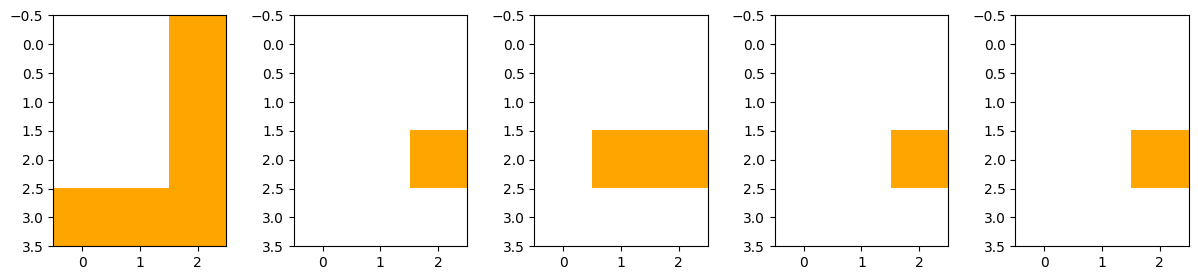

In [10]:
# We use the fact that the (0,3,2)-entry of the 3D array is the only one that is where
# correspond to the top rear corner of the structure 
# where the cross of the “T” meets the top of the “F”.

# Top-most view gives us an "L" that points to the left
zero_layer = tf.constant(
[       
        [0, 0, 1], # (0,0,0) (0,0,1) (0,0,2)
        [0, 0, 1], # (0,1,0) (0,1,1) (0,1,2)
        [0, 0, 1], # (0,2,0) (0,2,1) (0,2,2)
        [1, 1, 1], # (0,3,0) (0,3,1) (0,3,2)
])

# removing the top-most layer, we only have the cube corresponding to the height of the structure
first_layer = tf.constant(
[       
        [0, 0, 0], # (0,0,0) (0,0,1) (0,0,2)
        [0, 0, 0], # (0,1,0) (0,1,1) (0,1,2)
        [0, 0, 1], # (0,2,0) (0,2,1) (0,2,2)
        [0, 0, 0], # (0,3,0) (0,3,1) (0,3,2)
])

# removing the first layer, we have cube for the height of the structure, as well as the notch of the "F"
second_layer = tf.constant(
[       
        [0, 0, 0], # (0,0,0) (0,0,1) (0,0,2)
        [0, 0, 0], # (0,1,0) (0,1,1) (0,1,2)
        [0, 1, 1], # (0,2,0) (0,2,1) (0,2,2)
        [0, 0, 0], # (0,3,0) (0,3,1) (0,3,2)
])

# removing the second layer, we only have the cube for the height of the structure
third_layer = tf.constant(
[       
        [0, 0, 0], # (0,0,0) (0,0,1) (0,0,2)
        [0, 0, 0], # (0,1,0) (0,1,1) (0,1,2)
        [0, 0, 1], # (0,2,0) (0,2,1) (0,2,2)
        [0, 0, 0], # (0,3,0) (0,3,1) (0,3,2)
])

# removing the third layer, we only have the final cube for the height of the structure
fourth_layer = tf.constant(
[       
        [0, 0, 0], # (0,0,0) (0,0,1) (0,0,2)
        [0, 0, 0], # (0,1,0) (0,1,1) (0,1,2)
        [0, 0, 1], # (0,2,0) (0,2,1) (0,2,2)
        [0, 0, 0], # (0,3,0) (0,3,1) (0,3,2)
])

cmap = mcolors.ListedColormap(['white', 'orange'])
fig, axs = plt.subplots(1, 5, figsize=(15, 3))
axs[0].imshow(zero_layer, cmap = cmap)
axs[1].imshow(first_layer, cmap = cmap)
axs[2].imshow(second_layer, cmap = cmap)
axs[3].imshow(third_layer, cmap = cmap)
axs[4].imshow(fourth_layer, cmap = cmap)

In [8]:
# We use the fact that the (0,3,2)-entry of the 3D array is the only one that is where
# correspond to the top rear corner of the structure 
# where the cross of the “T” meets the top of the “F”.
tflogo = tf.stack( [zero_layer, 
                    first_layer, 
                    second_layer, 
                    third_layer, 
                    fourth_layer], axis = 0)
print(tflogo.shape)

(5, 4, 3)


## 2.) Ordinary Least Squares Linear Regression (5 points, spent $\approx$ _ minutes)

**This problem will walk you through building and fitting a simple linear regression model, expanding on the example from lecture. In particular, we will adapt the code from lecture to define a class `LinearModel` that encodes linear regression for p-dimensional data, instead of the 1-dimensional case from lecture. You are free to start from the lecture code, which is available in the demo notebook on the course webpage or canvas, or just copy-paste this (be mindful of weird indentation caused by copying from a pdf!):**

```python
class LinearModel(tf.Module):
    
    def __init__(self, name=None):
        super().__init__(name=name)
        self.W = tf.Variable([1.0], dtype=tf.float32, name="slope")
        self.b = tf.Variable([1.0], dtype=tf.float32, name="intercept")

    def __call__(self, x):
        return self.W * x + self.b
```

**Override the initialization method to take an optional argument `p`, and initialize `W` and `b` to be tensors with shapes `(p,)` and `(1,)`, respectively, with entries initialized to be independent standard normals.** 

**The argument `p` should default to `p=1` and your initialization method should raise an appropriate error in the event that this argument is not a positive integer.** 

**Note: in the Keras tutorials below, we’ll see a different way to do this using the `tf.keras.layers` submodule, which is expressly designed for specifying multilayer perceptrons and neural nets. For this problem, please just use TensorFlow Variable Tensor objects.**

**Implement an additional method `get_dimension` that takes no arguments (other than self) and returns the data dimension (i.e., the initialization argument `p`). You are free to store `p` as a class attribute or to simply read `p` from `self.W.shape`.**

**Implement the `__call__` method so that the input `x` is a `tf.Tensor` of shape `(n,p)`, where:**

* **`n` is a number of observations (not known ahead of time!).**

* **`p` is the dimension specified upon initialization.**

**That is, each row of `x` is a vector of `p` predictors. The output of the call should be a  `tf.Tensor` of shape `(n,)`, and should encode the prediction of the model applied to each row of `x`. There is no need to perform error checking for this method. We will leave it to TensorFlow to yell at us if x is of the wrong type or the wrong shape when we try to multiply it.** 

**Hint: you will be tempted to write something like `self.W * x + self.b`, but this will not work, owing to the shapes of `W` and `x`. Instead, look at the `tf.tensordot function` or use the matrix multiplication operator `@`.**

**As a sanity check, try running the following code snippet (this assumes that you have kept the names `W` and `b` for the slope and intercept; you’ll have to update it if you chose something different):**

```python
linear_model = LinearModel(p=3)
linear_model.W.assign([1.0,1.0,1.0])
linear_model.b.assign([1.0])
x = tf.constant([[0,1,2],[3,4,5]], dtype=tf.float32)
linear_model( x )
```

**The result should be a tensor that looks something like:**

```python
<tf.Tensor: shape=(2,), dtype=float32, numpy=array([ 4., 13.], dtype=float32)>
```

In [47]:
class LinearModel(tf.Module):
    
    def __init__(self, name = None, p = 1):
        super().__init__(name = name)

        if not isinstance(p, int):
            raise ValueError(f"p {(p)} must be an integer")
        elif p < 1:
            raise ValueError(f"p {(p)} must be a positive integer.")
        self.p = p

        self.W = tf.Variable(self.p * (1.0, ), dtype = tf.float32, name = "slope")
        self.b = tf.Variable((1.0, ), dtype = tf.float32, name = "intercept")
        
    def get_dimension(self):
        return self.p
    
    def __call__(self, x):
        return tf.tensordot(x, self.W, 1) + self.b

**Following the example from lecture, define a loss function loss that takes two arguments, `y_obsd` and `y_pred`, which are two `tf.Tensor` objects of the same shape `(n,)` for some positive integer `n`, and returns the mean squared error between the two vectors. That is, it computes:**

$$
\frac{1}{n}\bigg(\sum_{i=1}^{n} y^{(i)}_\text{obsd} - y^{(i)}_\text{pred} \bigg)^2
$$

**Note that the example from lecture uses `tf.reduce_sum`, so you’ll need to read the documentation to find out how to get a mean instead. There is no need to perform any error checking in this function.**

In [46]:
def loss(y_obsd, y_pred):
    return tf.reduce_mean(tf.square(y_obsd - y_pred))

**Continuing to follow the example from lecture, define a function `train` that takes a `LinearModel` object, a `tf.Tensor` `X` with shape `(n,p)`, a `tf.Tensor` `y` with shape `(n,)` and a float `step_size` (i.e., the learning rate parameter in the lecture code) as its arguments.**

```python
train( model, x, y, step_size )
```

**should compute the gradient of the loss with respect to the parameters and update the model parameters accordingly, scaling the gradient vector by `step_size`.**

In [ ]:
def train(model, x, y, step_size):
    with tf.GradientTape() as t:
        current_loss = loss(y, model(x))
        
        (dW, db) = t.gradient(current_loss, [model.W, model.b])
    
        model.W.assign_sub( step_size * dW )
        model.b.assign_sub( step_size * db )